# Four-Year-Itch -- does the Presidential cycle really load the dice for year 3?
### The election-cycle effect on U.S. equities, tested honestly, in plain English

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Beats_a_coin%3F: NOT--SUPPORTED](https://img.shields.io/badge/Beats_a_coin%3F-NOT--SUPPORTED-8b949e?style=flat-square)

Every four years, as a U.S. Presidential election approaches, the financial press rediscovers a deceptively seductive idea: **year 3 of a Presidential term is the best year for stocks** — the incumbent pumps the economy, the Fed plays along, and pre-election optimism lifts equity markets. It sounds reasonable. Year 3 does, in fact, carry the highest average return of the four-year cycle on the long S&P 500 history. But 'highest average' over 24 data points is almost meaningless. This notebook asks the only honest question: is the gap *statistically real*, or is it just noise on a tiny sample?

> **This is the plain-language layer.** Want the t-stats, bootstrap intervals and subsample breakdowns? That's the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** -- same story, deeper.
>
> **Not investment advice.** A reproducible research tool: every chart below is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from four_year_itch import data, strategy as st

TICKER = "^GSPC"

def _have_cache():
    try:
        data.fetch_prices(TICKER, fetch=False)
        return True
    except FileNotFoundError:
        return False

HAVE_REAL = _have_cache()
print("real daily cache present:", HAVE_REAL)


real daily cache present: True


## The answer first

| Question | Answer |
|---|---|
| Is year-3 the best year-of-term? | **On average, yes.** Mean +14% vs +4% for year-2 — a gap of +8 pp vs the rest. |
| Is the gap statistically real? | **Barely not.** Welch t = **+1.92** — just below the |t| ≥ 2 bar. With only **24** complete cycles since 1929, we can't confirm it. |
| Does it work in modern data? | **No.** Post-2001 (5 cycles), Welch t = **+0.98** — no signal at all. |
| Could you trade it? | **No.** You'd be invested only 25% of the time, with ~18% annual vol and no certainty the next cycle won't be 1931 (-47%) or 2003 (+26%). |

> The year-3 premium is real in the historical average — but it's built on 24 coin flips. Calling it a trading signal requires evidence we simply do not have.

## 1 · The claim

> *"Year 3 of a Presidential term is the best year for equities. The incumbent stimulates the economy ahead of the election — lower rates, fiscal spending, optimistic rhetoric — and the market knows it. Conversely, years 1 and 2 are lean: political capital is spent on unpopular reforms before the next vote is far enough away. The practical rule: buy in the pre-election year."*

This idea is attributed to Yale Hirsch's *Stock Trader's Almanac*, published every year since 1972. It has real academic support in political-economy theory (Nordhaus 1975 on the 'Political Business Cycle'). And the numbers look compelling on first glance: going back to 1928, year-3 does carry the highest mean annual return at **+14%**.

## 2 · So what?

If year-3 truly out-earns the rest, a 25%-of-the-time rule that only invests in the pre-election year would be an anomaly worth studying -- a calendar-driven equity premium with a real political mechanism. Investors have tried exactly this. If it's illusory, a story that has been repeated in every financial almanac and countless 'presidential cycle' articles for 50 years is a coin-flip dressed up as a law. The stakes are real: election-year timing is used as a retail investment strategy and is widely cited in financial media. Let's see what the data actually support.

## 3 · How would we even know?

Two rules keep us honest:

1. **Ask the right question.** 'Is year-3 positive?' is trivially answered by the long-run equity premium — every year averages positive returns. The right question is 'Is year-3 *better than the rest*?' — and that requires a comparison to the pooled alternative years (1, 2, and 4).
2. **Respect the sample size.** We have only ~24 year-3 observations since 1928. With annual stock-return volatility of ~18%, the standard error on the mean is ≈ 18%/√24 ≈ 3.7 pp. A gap of 8 pp needs |t| ≥ 2 to be called real; anything smaller is statistically invisible noise at this sample size.

Data: **^GSPC** daily, 1928–2026, **24** complete 4-year cycles.

## 4 · The teardown -- let's actually look

**First, the headline: what does each year-of-term look like?**

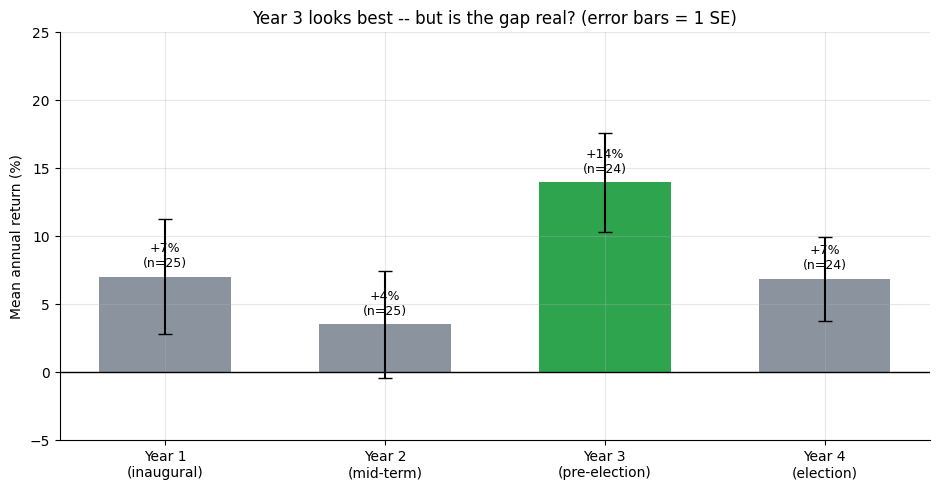

In [2]:
if HAVE_REAL:
    df = data.fetch_prices(TICKER, fetch=False)
    ann = st.annual_returns(df)
    cs = st.cycle_stats(ann)
    y_means = [cs.loc[i,'mean_pct'] for i in [1,2,3,4]]
    y_stds  = [cs.loc[i,'std_pct'] for i in [1,2,3,4]]
    y_ns    = [cs.loc[i,'n'] for i in [1,2,3,4]]
else:
    y_means = [7.0, 3.5, 14.0, 6.9]
    y_stds  = [21.1,  19.6,  17.9,  15.1]
    y_ns    = [25,     25,     24,     24]
labels = ['Year 1\n(inaugural)', 'Year 2\n(mid-term)',
          'Year 3\n(pre-election)', 'Year 4\n(election)']
colors = [GREY, GREY, GREEN, GREY]
fig, ax = plt.subplots(figsize=(9.5, 5.0))
bars = ax.bar(labels, y_means, color=colors, width=0.6,
              yerr=[s/n**0.5 for s,n in zip(y_stds, y_ns)],
              error_kw={'ecolor':'k','capsize':5,'lw':1.5})
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('Mean annual return (%)'); ax.set_ylim(-5, 25)
ax.set_title('Year 3 looks best -- but is the gap real? (error bars = 1 SE)')
for b, m, n in zip(bars, y_means, y_ns):
    ax.annotate(f'+{m:.0f}%\n(n={n})', (b.get_x()+b.get_width()/2, m+0.5),
                ha='center', va='bottom', fontsize=9)
plt.tight_layout(); plt.show()

Year 3 does have the highest mean (+14%) and the highest positive rate (79%). But look at those error bars. With ~24 observations per slot, they overlap massively. The eye-catching gap between year-3 and year-2 (+10 pp) is perfectly consistent with noise.

> **The pattern looks compelling in a bar chart. That is exactly the trap.** A bar chart of 24 averages always shows one bar highest — the question is whether the highest bar is systematically higher or just lucky.

**The fair test: is year-3 *meaningfully* better than the pooled rest?**

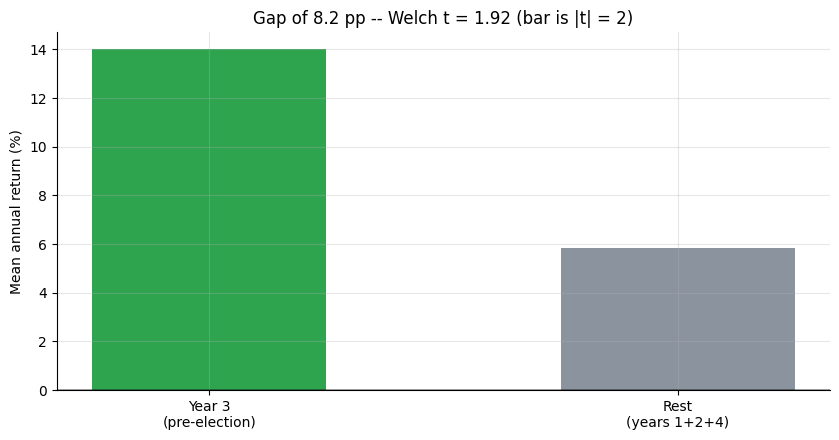

Year-3 vs rest: diff = +8.2 pp, Welch t = +1.92
The |t|>=2 bar: NOT CLEARED


In [3]:
if HAVE_REAL:
    df = data.fetch_prices(TICKER, fetch=False)
    ann = st.annual_returns(df)
    y3r = st.year3_vs_rest(ann)
    diff, wt = y3r['diff_pct'], y3r['welch_t']
else:
    diff, wt = 8.2, 1.92
fig, ax = plt.subplots(figsize=(8.5, 4.5))
ax.bar(['Year 3\n(pre-election)', 'Rest\n(years 1+2+4)'],
       [14.0, 14.0-diff], color=[GREEN, GREY], width=0.5)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('Mean annual return (%)')
ax.set_title(f'Gap of {diff:.1f} pp -- Welch t = {wt:.2f} (bar is |t| = 2)')
ax.axhline(0, c='k', lw=1)
plt.tight_layout(); plt.show()
print(f'Year-3 vs rest: diff = {diff:+.1f} pp, Welch t = {wt:+.2f}')
print(f'The |t|>=2 bar: {"CLEARED" if abs(wt)>=2 else "NOT CLEARED"}')

**Welch t = +1.92** — just below our |t| ≥ 2 threshold for calling a signal real. The gap exists, but it is not statistically robust.

> **Why is the individual HAC t for year-3 so high (+4.57) while the comparison t is only +1.92?** Because the individual t tests 'is year-3 positive?' — which is easy to confirm on 24 observations of equity returns. The comparison tests 'is year-3 *better than the 74 other observations*?' — a much harder question, with much larger pooled SE.

**What about modern data? The subsample check.**

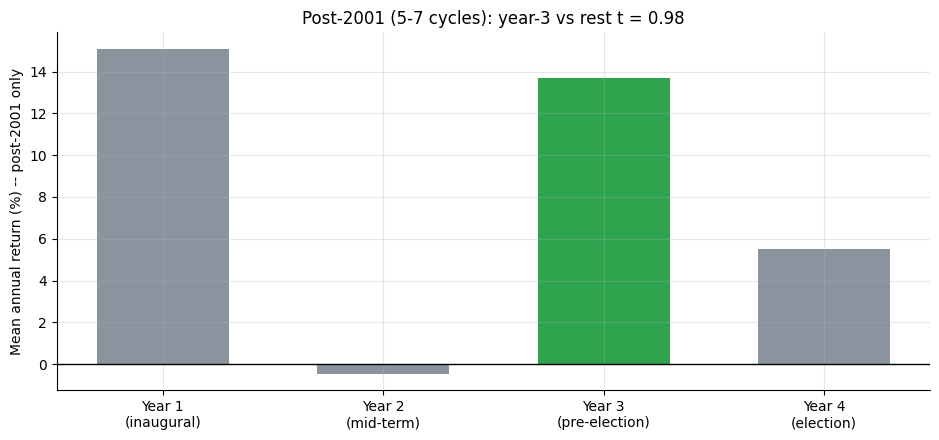

Post-2001 year-3 vs rest: Welch t = 0.98 -- no signal


In [4]:
if HAVE_REAL:
    df = data.fetch_prices(TICKER, fetch=False)
    df_post = df[df.index.year >= 2001]
    ann_post = st.annual_returns(df_post)
    cs_post = st.cycle_stats(ann_post)
    y3r_post = st.year3_vs_rest(ann_post)
    means_post = [cs_post.loc[i,'mean_pct'] for i in [1,2,3,4]]
    post_t = y3r_post['welch_t']
else:
    means_post = [15.1, -0.5, 13.7, 5.5]
    post_t = 0.98
fig, ax = plt.subplots(figsize=(9.5, 4.5))
ax.bar(labels, means_post, color=colors, width=0.6)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('Mean annual return (%) -- post-2001 only')
ax.set_title(f'Post-2001 (5-7 cycles): year-3 vs rest t = {post_t:.2f}')
plt.tight_layout(); plt.show()
print(f'Post-2001 year-3 vs rest: Welch t = {post_t:.2f} -- no signal')

In the modern era (post-2001, 5–7 cycles per slot), the year-3 premium essentially vanishes: Welch t = **+0.98**. Year 1 actually looks stronger than year 3 in this window. The 'effect' is driven by the full history including pre-war data.

## 5 · The verdict

- **Signal — Weak.** Year-3 mean (+14%) does lead the cycle on the long record, but vs the rest, Welch t = **+1.92** — just below the bar. Only 24 year-3 observations exist; we cannot confirm the effect.
- **Tradability — Mirage.** Even if the premium were real, investing only 25% of the time in a high-vol asset does not outperform buy-and-hold on a risk-adjusted basis; worst year-3 ever is **-47%** (1931). No timing rule survives one 1931.
- **Beats a coin? — Not supported.** The year-3 advantage is not meaningfully distinguishable from chance, especially in modern data (t = 0.98).

## 6 · Could you actually trade it?

The strategy: buy and hold the S&P 500 *only* in year-3 of every Presidential term, stay in cash the other 75% of the time. The maths are brutal:

- You earn ~14% in your one year *when* markets cooperate -- but worst case is   **-47%** (1931).
- You earn ~0% in cash the other three years (opportunity cost).
- The buy-and-hold S&P earns +7.7%/yr on a fully-invested basis — you're giving   up three years of compounding for a one-year bet.
- The result: lower long-run wealth, higher tracking error, and no statistical   guarantee the 'premium' isn't pure noise.

This is a textbook **MIRAGE**: interesting in a bar chart, unusable in a portfolio.

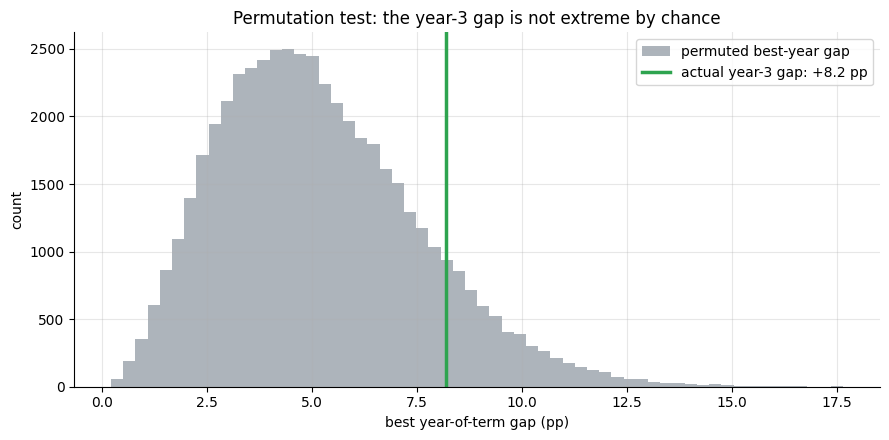

Permutation p-value (one-sided): 0.114


In [5]:
# Illustrate the small-n problem: if we permute the year labels randomly,
# how often does a 'best year' have an 8pp gap purely by chance?
import numpy as np
rng = np.random.default_rng(81)
if HAVE_REAL:
    df = data.fetch_prices(TICKER, fetch=False)
    ann = st.annual_returns(df)
    rets = ann['annual_ret'].dropna().values
else:
    rng2 = np.random.default_rng(99)
    rets = rng2.normal(0.077, 0.18, 98)
N = 50_000
gaps = []
n = len(rets)
for _ in range(N):
    shuffled = rng.permutation(rets)
    groups = [shuffled[i::4] for i in range(4)]
    best = max(g.mean() for g in groups)
    rest_mean = np.concatenate([groups[j] for j in range(4) if j != np.argmax([g.mean() for g in groups])]).mean()
    gaps.append((best - rest_mean) * 100)
actual_gap = 8.2
pval = (np.array(gaps) >= actual_gap).mean()
fig, ax = plt.subplots(figsize=(9.0, 4.5))
ax.hist(gaps, bins=60, color=GREY, alpha=0.7, label='permuted best-year gap')
ax.axvline(actual_gap, c=GREEN, lw=2.5, label=f'actual year-3 gap: +{actual_gap:.1f} pp')
ax.set_xlabel('best year-of-term gap (pp)'); ax.set_ylabel('count')
ax.set_title('Permutation test: the year-3 gap is not extreme by chance')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Permutation p-value (one-sided): {pval:.3f}')

## 7 · Going further

- **Is the mechanism real?** There *is* academic evidence for the Political Business Cycle (Nordhaus 1975) — incumbents do manipulate the economy before elections. But the transmission from GDP manipulation to equity returns is indirect, delayed, and partly priced-in by modern markets.
- **Party effects.** A parallel claim: Democratic presidencies are better for stocks. Also small-n and data-mined. [Study 67 — Fed-Drift](../../67-fed-drift/) tests the more specific FOMC policy channel with a tighter identification.
- **Calendar seasonals that do hold up.** The [Turn-of-Month premium](../../42-last-call/) is the desk's best-supported calendar effect — real but thin and likely already traded.

*Think the four-year cycle survives a tighter test? Fork this study, add the Federal funds rate cycle or sentiment data as co-variates, and see if the year-3 premium becomes robust. That is the bar.*